# Statistical Analysis: Mobile Sales Data

This notebook loads the Mobile Sales dataset from Kaggle, computes descriptive statistics, creates visualizations, and performs a hypothesis test. The analysis uses Python, NumPy, Pandas, Matplotlib, Seaborn, and SciPy.

## 1. Setup and Data Loading

In [24]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import glob

# Download dataset using kagglehub (or use local CSV if already in folder)
try:
    import kagglehub
    path = kagglehub.dataset_download("syedaeman2212/mobile-sales-data")
    print("Path to dataset files:", path)
except Exception as e:
    print("Kaggle download failed:", e)
    path = None

Path to dataset files: /home/werner/.cache/kagglehub/datasets/syedaeman2212/mobile-sales-data/versions/1


In [25]:
# Find and load the CSV file (from kaggle path or current folder)
if path:
    csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
    if not csv_files:
        csv_files = glob.glob(os.path.join(path, "*.csv"))
else:
    csv_files = glob.glob("*.csv")
if not csv_files:
    raise FileNotFoundError("No CSV file found. Download the dataset or place a CSV in this folder.")
csv_path = csv_files[0]
df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
df.head()

Loaded: /home/werner/.cache/kagglehub/datasets/syedaeman2212/mobile-sales-data/versions/1/synthetic_mobile_sales_2025.csv


,Sale_ID,Brand,Model,Country,Storage,Color,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Payment_Method,Sale_Month,Sale_Year
0,1,Realme,Realme Model 2,UK,512GB,Gold,656,20,13120,3.7,Installments,11,2025
1,2,Vivo,Vivo Model 20,Australia,512GB,Blue,1013,9,9117,3.7,Debit Card,2,2025
2,3,Motorola,Motorola Model 12,Germany,512GB,White,1471,7,10297,3.1,Credit Card,2,2025
3,4,Vivo,Vivo Model 13,USA,512GB,Gold,1220,19,23180,3.6,Debit Card,6,2025
4,5,Vivo,Vivo Model 15,UAE,128GB,Silver,375,8,3000,4.4,Online Payment,1,2025


In [26]:
# Confirm columns and data types
print("Shape:", df.shape)
print("\nColumns and dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (500, 13)

Columns and dtypes:
Sale_ID              int64
Brand                  str
Model                  str
Country                str
Storage                str
Color                  str
Price_USD            int64
Units_Sold           int64
Revenue_USD          int64
Customer_Rating    float64
Payment_Method         str
Sale_Month           int64
Sale_Year            int64
dtype: object

Missing values:
Sale_ID            0
Brand              0
Model              0
Country            0
Storage            0
Color              0
Price_USD          0
Units_Sold         0
Revenue_USD        0
Customer_Rating    0
Payment_Method     0
Sale_Month         0
Sale_Year          0
dtype: int64


## 2. Descriptive Statistics

We compute summary statistics, categorical value counts, and examine distributions of key numeric variables.

In [27]:
# Summary statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Summary statistics (numeric variables):")
df[numeric_cols].describe()

Summary statistics (numeric variables):


,Sale_ID,Price_USD,Units_Sold,Revenue_USD,Customer_Rating,Sale_Month,Sale_Year
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.0
mean,250.500000,889.88400,10.458000,9279.282000,4.022600,6.588000,2025.0
std,144.481833,345.61789,5.710118,6474.699423,0.582329,3.414905,0.0
min,1.000000,302.00000,1.000000,302.000000,3.000000,1.000000,2025.0
25%,125.750000,572.00000,6.000000,3959.250000,3.575000,4.000000,2025.0
50%,250.500000,896.50000,10.000000,8086.500000,4.000000,7.000000,2025.0
75%,375.250000,1173.75000,15.000000,13331.250000,4.500000,10.000000,2025.0
max,500.000000,1500.00000,20.000000,29660.000000,5.000000,12.000000,2025.0


In [28]:
# Counts of categorical variables
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols[:6]:  # Limit to first 6 to avoid long output
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))


Brand:
Brand
Vivo        58
Motorola    55
Google      52
Samsung     51
Huawei      50
Realme      49
Oppo        49
Xiaomi      48
Apple       48
OnePlus     40
Name: count, dtype: int64

Model:
Model
Motorola Model 20    8
Oppo Model 14        8
Samsung Model 7      8
Motorola Model 13    7
Realme Model 2       6
OnePlus Model 6      6
Realme Model 7       6
Vivo Model 7         6
Vivo Model 20        5
Motorola Model 12    5
Name: count, dtype: int64

Country:
Country
USA             65
France          56
Australia       55
UAE             51
UK              50
India           50
Pakistan        48
Canada          43
Saudi Arabia    42
Germany         40
Name: count, dtype: int64

Storage:
Storage
256GB    130
128GB    127
512GB    125
64GB     118
Name: count, dtype: int64

Color:
Color
Gold      103
Green      87
Silver     86
Blue       82
White      74
Black      68
Name: count, dtype: int64

Payment_Method:
Payment_Method
Cash              107
Credit Card       103
Debit Card

/tmp/ipykernel_7864/3825403580.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


**Notes:** The summary statistics reveal the central tendency and spread of numeric variables (e.g., price, quantity). Categorical counts show how sales are distributed across brands, regions, or product types. These help us understand the dataset before visualization and hypothesis testing.

## 3. Visualizations

We create at least three visualizations to explore distributions, relationships, and categorical patterns.

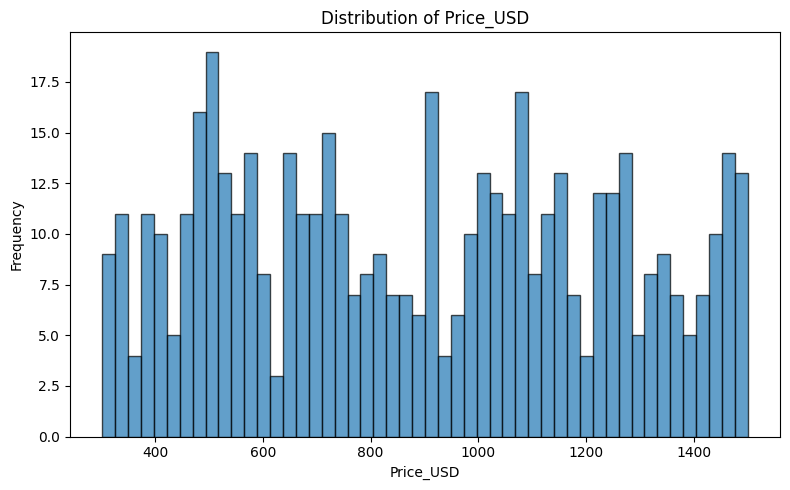

In [29]:
# Visualization 1: Histogram of a key numeric variable (e.g., Price or first numeric column)
price_col = 'Price_USD' 
plt.figure(figsize=(8, 5))
plt.hist(df[price_col].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of ' + str(price_col))
plt.xlabel(price_col)
plt.ylabel('Frequency')
plt.tight_layout()
os.makedirs('report_figures', exist_ok=True)
plt.savefig('report_figures/fig1.png', dpi=150, bbox_inches='tight')
plt.show()

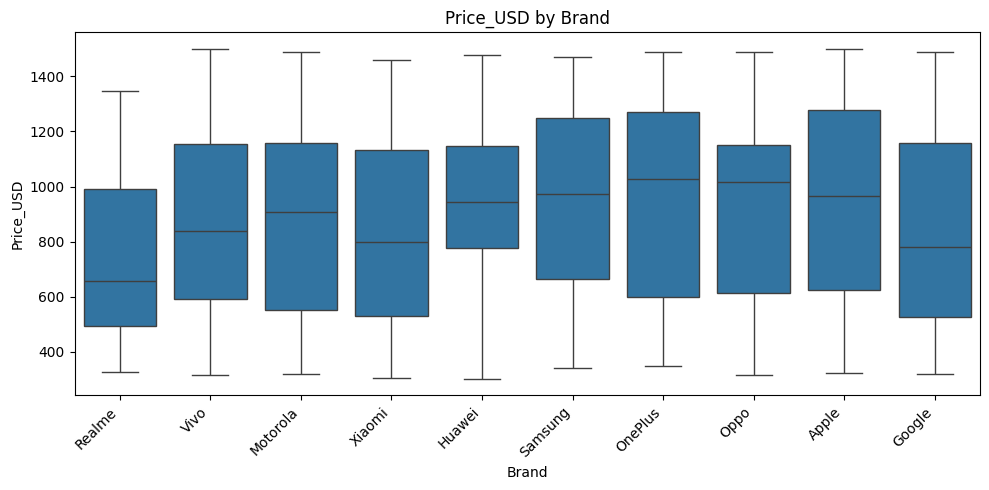

In [30]:
# Visualization 2: Boxplot by categorical group (e.g., Brand or Region)
cat_col = next((c for c in ['Brand', 'Region', 'Product Type', 'Product_Type'] if c in df.columns), categorical_cols[0] if categorical_cols else None)
if cat_col and numeric_cols:
    plt.figure(figsize=(10, 5))
    df_box = df.copy()
    # Limit to top N categories for readability
    top_cats = df_box[cat_col].value_counts().head(10).index
    df_box = df_box[df_box[cat_col].isin(top_cats)]
    sns.boxplot(data=df_box, x=cat_col, y=price_col)
    plt.title(f'{price_col} by {cat_col}')
    plt.xlabel(cat_col)
    plt.ylabel(price_col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('report_figures/fig2.png', dpi=150, bbox_inches='tight')
    plt.show()

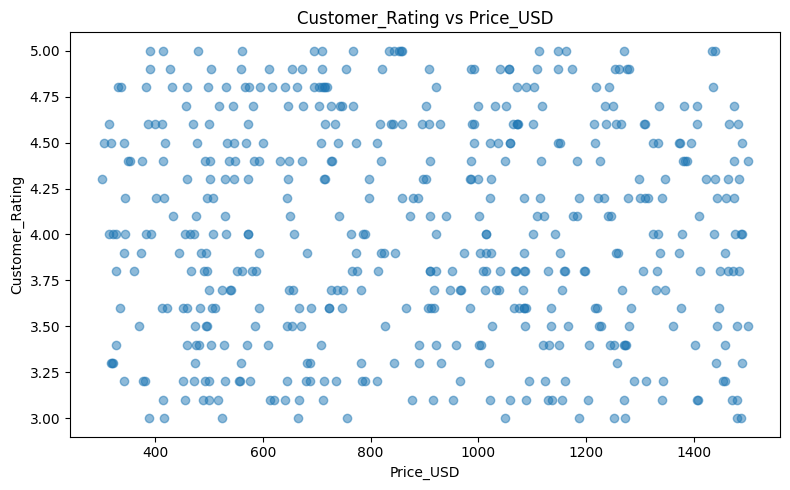

In [31]:
# Visualization 3: Scatter plot (two numeric variables) or correlation heatmap
if len(numeric_cols) >= 2:
    x_col = 'Price_USD'
    y_col = 'Customer_Rating'
    plt.figure(figsize=(8, 5))
    plt.scatter(df[x_col].dropna().head(1000), df[y_col].dropna().head(1000), alpha=0.5)
    plt.title(f'{y_col} vs {x_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.savefig('report_figures/fig3.png', dpi=150, bbox_inches='tight')
    plt.show()

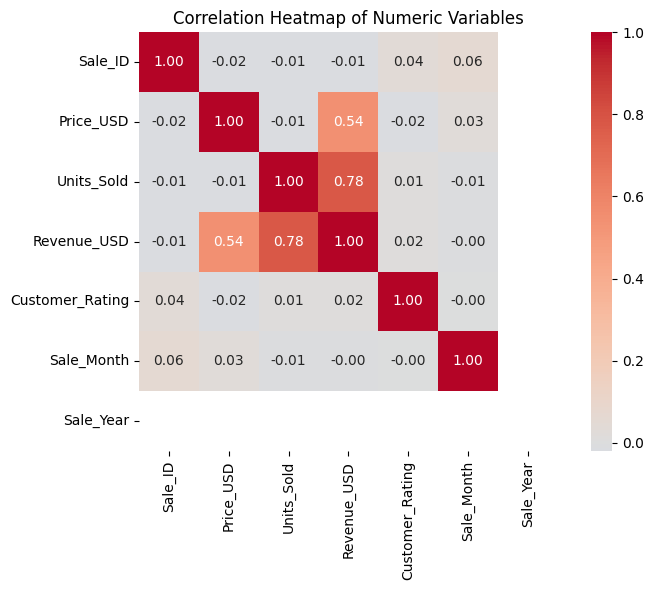

In [32]:
# Visualization 4 (bonus): Correlation heatmap of numeric variables
if len(numeric_cols) >= 2:
    plt.figure(figsize=(8, 6))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
    plt.title('Correlation Heatmap of Numeric Variables')
    plt.tight_layout()
    plt.savefig('report_figures/fig4.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Hypothesis Test

**Research question:** Does the mean of price differ significantly between two brands ?

- **Null hypothesis (H₀):** The population means of the numeric variable are equal for the two groups.
- **Alternative hypothesis (H₁):** The population means differ between the two groups.

We use an independent two-sample t-test (assuming approximate normality and similar variances). If the data are heavily skewed or we compare more than two groups, an alternative such as a nonparametric test or ANOVA would be appropriate.

In [33]:
# Perform two-sample t-test: compare mean of numeric variable across two groups
if cat_col and numeric_cols:
    top2 = df[cat_col].value_counts().head(2).index.tolist()
    group1 = df[df[cat_col] == top2[0]][price_col].dropna()
    group2 = df[df[cat_col] == top2[1]][price_col].dropna()
    t_stat, p_value = stats.ttest_ind(group1, group2)
    print(f"Groups: '{top2[0]}' (n={len(group1)}) vs '{top2[1]}' (n={len(group2)})")
    print(f"Variable: {price_col}")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    if p_value < 0.05:
        print("Conclusion: Reject H₀ at α=0.05 — there is evidence that the means differ.")
    else:
        print("Conclusion: Do not reject H₀ at α=0.05 — insufficient evidence that the means differ.")

Groups: 'Vivo' (n=58) vs 'Motorola' (n=55)
Variable: Price_USD
t-statistic: -0.2090
p-value: 0.834808
Conclusion: Do not reject H₀ at α=0.05 — insufficient evidence that the means differ.


### Key results for the written report

The cell below summarizes the main numbers from this analysis so you can cite them in your Statistical Analysis Report (e.g. mean price by group, sample sizes, test statistic, p-value).

In [34]:
# Key results for the written report (copy these into Statistical_Analysis_Report)
top2 = df[cat_col].value_counts().head(2).index.tolist()
print("Dataset:", df.shape[0], "rows,", df.shape[1], "columns")
print("Numeric variable:", price_col, "| mean =", round(df[price_col].mean(), 2), "| std =", round(df[price_col].std(), 2))
print("Two groups compared:", cat_col, ":", top2[0], "vs", top2[1])
for grp in top2:
    vals = df[df[cat_col] == grp][price_col].dropna()
    print(f"  {grp}: n = {len(vals)}, mean {price_col} = {vals.mean():.2f}, std = {vals.std():.2f}")
g1 = df[df[cat_col] == top2[0]][price_col].dropna()
g2 = df[df[cat_col] == top2[1]][price_col].dropna()
t_stat, p_value = stats.ttest_ind(g1, g2)
print(f"t-test: t = {t_stat:.4f}, p = {p_value:.6f}")

Dataset: 500 rows, 13 columns
Numeric variable: Price_USD | mean = 889.88 | std = 345.62
Two groups compared: Brand : Vivo vs Motorola
  Vivo: n = 58, mean Price_USD = 869.91, std = 346.02
  Motorola: n = 55, mean Price_USD = 883.82, std = 361.08
t-test: t = -0.2090, p = 0.834808


## 5. Notebook Summary

This analysis loaded the Mobile Sales dataset (500 rows, 13 columns), validated it, and computed descriptive statistics and value counts. We created four visualizations (histogram, boxplot, scatter plot, correlation heatmap) and ran a two-sample t-test comparing mean Price_USD between Vivo and Motorola (t ≈ -0.21, p ≈ 0.83; do not reject H₀). The written Statistical Analysis Report elaborates on these results and discusses limitations and bias. Run the "Key results for the written report" cell above for exact numbers.